In [1]:
from AutoencoderAPI.recurrentTriplet import recurrentTriplet
from AutoencoderAPI.fileBatch import fileBatch
from AutoencoderAPI.fileBatchtSNE import fileBatchtSNE
from AutoencoderAPI.encoderStack import encoderStack
from AutoencoderAPI.transformer import transformer
from AutoencoderAPI.utils.plot import load_run_results, load_sweep_results, load_run_results_2D
from AutoencoderAPI.sweep import sweep

### Configuration

#### Triplet config

In [2]:
run_config_Triplet = {
'files' : {
        'dataset'                  : "Datasets/SNSPD/Paderborn/data train",
        'path_save'                : 'AutoencoderLog/',
        'input_dimension'          : 30_000, 
        'folder_type'              : 'npy'
        },
'network' : {
        'network_type'             : 'dropout',
        'activation_list'          : ['ReLU', 'ReLU', 'ReLU', 'ReLU', 'ReLU', 'ReLU', 'ReLU'],
        'layer_list'               : [100, 100, 100, 2, 100, 100, 100],
        'CNN_channels'             : [10, 10, 2, 10, 10, 10],
        'layer_type'               : 'Linear',
        'bw_cst'                   : [0.007]
        },
'train' : {
        'optimizer'                : 'Adam',
        'alpha'                    : 0.002,    #0.002
        'epochs_MSE'               : 0,
        'epochs_triplet'           : 5,
        'skip_elements'            : 1,
        'interval'                 : [3250,4250],
        'learning_rate_MSE'        : 1e-4,
        'learning_rate_triplet'    : 1e-6
        }
}

In [3]:
run_config_Triplet = {
'files' : {
        'dataset'                  : "Datasets/TES/NIST train",
        'path_save'                : 'AutoencoderLog/',
        'input_dimension'          : 8192, 
        'folder_type'              : None,
        'dB'                       : [23.5, 24.,  24.5, 25.,  25.5, 26.,  26.5, 27.,  27.5, 28.,  28.5, 29. ]
        },
'network' : {
        'network_type'             : 'CNN',
        'activation_list'          : ['CELU', 'CELU', 'CELU', 'CELU', 'CELU', 'CELU','CELU'],#['ReLU', 'ReLU', 'ReLU', 'ReLU', 'ReLU', 'ReLU', 'ReLU'],#['Hardshrink', 'LeakyReLU', 'PReLU', 'LeakyReLU', 'Hardshrink'],#['Mish', 'CELU', 'Tanh', 'CELU', 'Mish'],
        'layer_list'               : [100, 100, 100, 2, 100, 100, 100],
        'CNN_channels'             : [1, 10, 10, 10, 1, 10, 10, 10, 1],
        'layer_type'               : 'Linear',
        'bw_cst'                   : [0.007]
        },
'train' : {
        'optimizer'                : 'Adam',
        'alpha'                    : 0.01,    #0.002
        'number_cluster'           : 35,
        'epochs_MSE'               : 0,
        'epochs_triplet'           : 10,
        'skip_elements'            : 1,
        'interval'                 : [0,350],
        'learning_rate_MSE'        : 1e-4,
        'learning_rate_triplet'    : 5e-7
        }
}

#### MSE config

In [4]:
run_config_MSE = {
'files' : {
        'dataset'                  : "Datasets/SNSPD/Paderborn/data train",
        'path_save'                : 'AutoencoderLog/',
        'input_dimension'          : 30_000,
        'folder_type'              : 'npy',
        'dB'                       : [23.5, 24.,  24.5, 25.,  25.5, 26.,  26.5, 27.,  27.5, 28.,  28.5, 29. ]
        },
'network' : {
        'network_type'             : 'generic',
        'activation_list'          : ['ReLU', 'ReLU', 'ReLU', 'ReLU', 'ReLU'],#['CELU', 'Mish', 'Tanh', 'Mish', 'CELU'],#['Hardshrink', 'LeakyReLU', 'PReLU', 'LeakyReLU', 'Hardshrink']
        'layer_list'               : [100, 100, 1, 100, 100],
        'layer_type'               : 'Linear'
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'MSELoss',#'MSELoss', 
        'k-fold'                   : 2,
        'batch_number'             : 4,
        'epochs'                   : 3,
        'skip_elements'            : 0,
        'interval'                 : [3250,4250],#[3250,4500],
        'learning_rate'            : 1e-4
        },
'dB' : 15.99
}

In [5]:
run_config_MSE = {
'files' : {
        'dataset'                  : "Datasets/TES/NIST train",
        'path_save'                : 'AutoencoderLog/',
        'input_dimension'          : 8192,
        'folder_type'              : None,
        'dB'                       : [23.5, 24.,  24.5, 25.,  25.5, 26.,  26.5, 27.,  27.5, 28.,  28.5, 29. ]
        },
'network' : {
        'network_type'             : 'CNN',
        'activation_list'          : ['CELU', 'CELU', 'CELU', 'CELU','CELU'],
        'layer_list'               : [200, 200, 2, 200, 200],
        'layer_type'               : 'Linear'
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'MSELoss',#'tSNE', #MSELoss
        'k-fold'                   : 10,
        'batch_number'             : 1,
        'epochs'                   : 5,
        'skip_elements'            : 0,
        'interval'                 : [0,350],
        'learning_rate'            : 8e-05
        }
}

#### Transformer config

In [6]:
run_config_Transformer = {
'files' : {
        'dataset'                  : "Datasets/NIST (250)",
        'path_save'                : 'AutoencoderLog/',
        'input_dimension'          : 8192,
        'folder_type'              : None
        },
'network' : {
        'nhead'                    : 250,
        'dropout'                  : 0.1,
        'sequence_len'             : 10,
        'encoding_dim'             : 2    
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'MSELoss',
        'skip_elements'            : 1,
        'interval'                 : [0,270],
        'epochs'                   : 6,
        'learning_rate'            : 1e-6
        }
}

### CNN config

In [7]:
run_config_CNN = {
'files' : {
        'dataset'                  : "Datasets/TES/NIST train",
        'path_save'                : 'AutoencoderLog/',
        'input_dimension'          : 8192,
        'folder_type'              : None
        },
'network' : {
        'activation_list'          : ['Mish', 'CELU', 'CELU', 'Tanh', 'CELU', 'CELU','Mish'],
        'layer_list'               : [200, 200, 200, 2, 200, 200, 200],
        'layer_type'               : 'Linear'
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'MSELoss',#'tSNE', #MSELoss
        'k-fold'                   : 2,
        'batch_number'             : 1,
        'epochs'                   : 4,
        'skip_elements'            : 1,
        'interval'                 : [0,270],
        'learning_rate'            : 1e-6
        }
}

### Run

In [8]:
func = recurrentTriplet()
#func = fileBatch()
#func = fileBatchtSNE()
#func = transformer()
func.run(run_config_Triplet)
"""
es = encoderStack()
es.train(run_config_MSE,
        stack_name = ' 5stack',
        step_number = 3,
        flip = False,
        bw = 0.025)
"""

Epoch MSE: 0it [00:00, ?it/s]

Epoch Triplet:   0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Sweep

In [ ]:
sweep_config = {
    'sweep_name'               : 'grid-search-TES 2D CNN 3',
    'search_param'             : [('train','epochs'),
                                  ('train','learning_rate')],
                               # [('network','activation_possibilty'), # 
                               #  ('network','layer_size_possibility')],   #
    'epochs'                   : [3,4,5,6], #
    'learning_rate'            : [1e-5, 2e-5, 4e-5, 6e-5, 8e-5, 1e-6, 2e-6, 4e-6, 6e-6, 8e-6, 1e-7, 2e-7, 4e-7, 6e-7, 8e-7],
    'alpha'                    : [1e1, 1e0, 1e-1, 1e-2, 1e-3, 1e-4],
    'activation_possibilty'    : ['ReLU', 'Sigmoid', 'CELU', 'Softmax', 'Softmin', 'Hardshrink', 
                                    'LeakyReLU', 'ELU', 'LogSigmoid', 'PReLU', 'GELU', 'SiLU', 
                                    'Mish', 'Softplus', 'Softsign', 'Tanh'],
    'layer_size_possibility'   : [50,100]
}

In [ ]:
exp = sweep()
#exp.random_search(run_config_MSE, sweep_config, 20)
#exp.grid_search(run_config_Triplet, sweep_config)

### Load Run

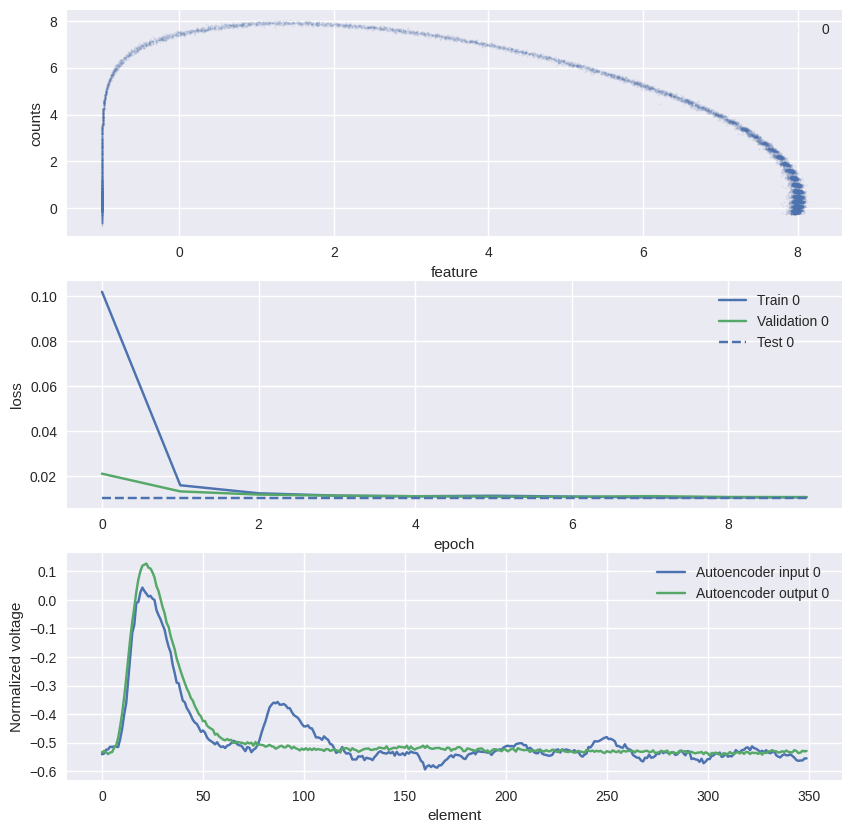

In [ ]:
#load_run_results("AutoencoderLog/grid-search-TES Triplet uniform/run 35", bw=[0.1], clustering=False, print_network=True, print_train=False)
load_run_results_2D("AutoencoderLog/run-2024-03-14-11-21")#grid-search-TES 2D CNN/run 19 03

### Load Sweep

In [ ]:
import numpy as np
nx, ny = 3, 3
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
xv, yv = np.meshgrid(x, y)
print(x, y)
print(xv, yv)

[0.  0.5 1. ] [0.  0.5 1. ]
[[0.  0.5 1. ]
 [0.  0.5 1. ]
 [0.  0.5 1. ]] [[0.  0.  0. ]
 [0.5 0.5 0.5]
 [1.  1.  1. ]]


In [ ]:
load_sweep_results("grid-search-TES 2D CNN 2", ["epochs","learning_rate"])

min :  0.004540964720154526
file : run 05
epochs :  3
learning_rate :  1e-05
[0.005748179428904874, 0.00612647154944474, 0.004897026886865346, 0.005195909208688298, 0.007321354278879089, 0.004540964720154526, 0.004792354096377674, 0.006081465230785632, 0.004714635423216752, 0.005134482524714681, 0.006159607701093057]


ValueError: cannot reshape array of size 11 into shape (1,1)